# Phase 2: Data Pipeline

## Objective

Phase 1 conducted exploratory data analysis on the raw sources
and established that 1,713 films possess all four required
signals (screenplay, IMDb rating, budget, revenue). Phase 2
transforms those raw sources into the canonical processed
artifact that all downstream phases consume:

* `data/processed/films_joined.parquet` — one row per film,
  containing all source columns, derived columns
  (`effective_rating`, `log_budget`, `log_revenue`,
  `primary_genre`, `genres_bucketed`, `primary_genre_bucketed`),
  and screenplay-structural metrics (`n_scenes`,
  `n_unique_characters`, `n_dialogue_lines`, character / action /
  dialogue character counts, two dialogue-to-action ratios).
* `data/processed/screenplays_parsed.pkl` — pickle of
  `dict[imdb_id, ParsedScreenplay]` containing the full
  per-scene structure (dialogue units, stage directions, scene
  descriptions). Phase 3 reads both files: the master table for
  metadata and outcomes, the per-scene structure for feature
  extraction.

Each preprocessing step in this notebook is paired with the
rationale that motivates it, drawn from the Phase 1 EDA or from
established ML practice. Cells should be executed sequentially.
The implementation lives under `src/data/`; this notebook
invokes the production functions and surfaces the intermediate
states for inspection and reporting.

## 0. Environment setup

The bootstrap cell resolves the project root by walking the
directory tree until `docs/PROJECT_CONTEXT.md` is found, then
adds it to `sys.path` so the project's package imports
(`from src... import ...`) succeed regardless of the notebook's
location. The `%autoreload 2` directive ensures that edits to
any module under `src/` propagate into the notebook without
requiring a kernel restart, which supports iterative
development. Inline plotting is enabled via the `inline`
backend.

In [32]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Walk up the directory tree until docs/PROJECT_CONTEXT is found."""
    markers = ("docs/PROJECT_CONTEXT.md", "docs/PROJECT_CONTEXT.txt")
    for candidate in (start.resolve(), *start.resolve().parents):
        if any((candidate / m).is_file() for m in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {start!s}.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")
get_ipython().run_line_magic("matplotlib", "inline")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Project root: /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports and path constants used throughout the notebook.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import paths

paths.ensure_dirs()

print("Data raw dir:    ", paths.DATA_RAW_DIR)
print("Data processed:  ", paths.DATA_PROCESSED_DIR)
print("Reports figures: ", paths.REPORTS_FIGURES_DIR)

Data raw dir:     /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project/data/raw
Data processed:   /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project/data/processed
Reports figures:  /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project/reports/figures


---

## 1. Load the raw data sources

The pipeline operates on two raw inputs.

**Ratings dataset.** The IMDb-TMDB Movie Metadata source
provides approximately 1.07M films, with budget, revenue,
runtime, multiple rating fields (TMDB user rating, IMDb user
rating, Metacritic score), genre lists, director, and
production companies. The source carries IMDb IDs natively,
permitting an exact-identifier join with MovieSum. The loader
is column-selective: of the 42 columns in the raw file, the
pipeline reads the 20 columns relevant to downstream tasks,
which keeps the in-memory footprint manageable.

**MovieSum corpus** (Saxena & Keller, ACL 2024). 2,200 movie
screenplays in structured XML format, distributed as JSONL
across train, validation, and test splits. Each screenplay is
tagged with an IMDb ID, enabling identifier-based joins. The
train / validation / test split inherited from the source is
intended for a different upstream task (abstractive
summarization) and is not used in this project; the
train / calibration / test partition for the present work is
constructed in Phase 3.

In [34]:
from src.data.load_ratings import load_ratings, summarize_ratings
from src.data.load_moviesum import load_moviesum, imdb_id_validity

ratings = load_ratings()
print(f"Ratings dataset: {len(ratings):,} films, {len(ratings.columns)} columns")
print(f"  Headline counts: {summarize_ratings(ratings)}")

moviesum = load_moviesum()
print(f"MovieSum corpus: {len(moviesum):,} screenplays")
print(f"  IMDb ID validity: {imdb_id_validity(moviesum)}")

2026-05-03 00:52:04 | INFO    | src.data.load_ratings | Loading ratings dataset (~20-30s)
2026-05-03 00:52:13 | INFO    | src.data.load_ratings | Loaded ratings: 1,072,255 rows | 588,585 unique IMDb IDs | 1,071,607 unique TMDB ids
Ratings dataset: 1,072,255 films, 22 columns
  Headline counts: {'total': 1072255, 'with_budget': 54415, 'with_revenue': 20264, 'with_both': 13759, 'with_imdb_id': 589364}
2026-05-03 00:52:13 | INFO    | src.data.load_moviesum | Loading MovieSum (train + val + test, ~5-10s)
2026-05-03 00:52:14 | INFO    | src.data.load_moviesum | Loaded MovieSum: 2,200 screenplays
MovieSum corpus: 2,200 screenplays
  IMDb ID validity: {'total': 2200, 'valid_imdb_id': 2200, 'invalid_or_missing': 0, 'unique_valid_ids': 2188}


The MovieSum IMDb ID validity report shows 2,200 well-formed
IDs but only 2,188 unique values: twelve IDs appear on two
rows each. These pairs are addressed in Section 3.

---

## 2. Deduplicate the ratings dataset on IMDb ID

**Justification.** A small fraction of films in the ratings
dataset appear under more than one TMDB identifier for the
same IMDb ID. These multi-entry cases correspond to alternate
cuts, regional releases, and director's cuts of the same
underlying film. For the purposes of this project they
represent a single film, and joining MovieSum to all variants
would introduce spurious duplicate rows in downstream
analyses.

**Strategy.** For each IMDb ID, retain the row with the
highest `vote_count` and discard the remaining variants. The
`vote_count` field is a recognition proxy: the higher-vote
variant is the better-known release of the film and is more
likely to have populated budget, revenue, and rating fields.
Films with no IMDb ID at all are dropped at this step because
they cannot participate in the join with MovieSum.

**Alternative considered.** Selecting by `popularity` was
rejected because that field is recency-biased and would
systematically prefer recent re-releases over canonical
original releases. Selecting by `vote_average` was rejected
because rating measures film quality, not recognition, and is
therefore less aligned with the goal of choosing the
canonical entry.

In [35]:
from src.data.join_corpus import dedupe_ratings

# `dedupe_ratings` is implemented in src/data/join_corpus.py.
# It drops rows lacking an imdb_id and retains the
# highest-vote_count row per remaining imdb_id.
ratings_dedup = dedupe_ratings(ratings)
print(f"Ratings deduped: {len(ratings_dedup):,} films "
      f"(reduced from {len(ratings):,})")

2026-05-03 00:52:14 | INFO    | src.data.join_corpus | Dedup ratings by IMDb ID: 1072255 → 588585 (483670 dropped, 482891 had no IMDb ID)
Ratings deduped: 588,585 films (reduced from 1,072,255)


---

## 3. Deduplicate MovieSum using the curated review file

**Justification.** Twelve IMDb IDs in MovieSum are associated
with two rows each, corresponding to either alternate-title
variants of the same screenplay (for example M\*A\*S\*H
and MASH share IMDb ID `tt0066026`) or substantively
different drafts of the same film. The pairs are not
homogeneous, so a single automated rule (such as "retain the
longest script") is insufficient. Manual review of each pair,
including structural counts and script previews, was
conducted in Phase 1 and the per-pair decisions were recorded
in `reports/tables/phase1_moviesum_duplicates_review.csv`.

**Strategy.** The pipeline reads the curated review file and
applies the recorded `keep` / `drop` decision per row. The
function recognizes `keep` for retention and any of `drop`,
`remove`, `delete`, `discard` for removal, providing
tolerance for natural language synonymy in the curated file.
Rows with missing or unrecognized decisions, or pairs whose
decisions do not resolve to exactly one retention and one
removal, raise an explicit error rather than silently
defaulting; this ensures that only fully-curated pairs are
applied.

In [36]:
# Inspect the curated review file to confirm what is being applied.
review_csv = paths.REPORTS_TABLES_DIR / "phase1_moviesum_duplicates_review.csv"
review_df = pd.read_csv(review_csv)
print(f"Curated review file: {len(review_df)} rows across "
      f"{review_df['imdb_id'].nunique()} IMDb IDs")
print(f"Decision distribution: {review_df['decision'].value_counts(dropna=False).to_dict()}")
review_df[["imdb_id", "movie_name", "year_in_title", "origin_split",
           "script_char_len", "decision"]].head(10)

Curated review file: 24 rows across 12 IMDb IDs
Decision distribution: {'keep': 12, 'remove': 12}


,imdb_id,movie_name,year_in_title,origin_split,script_char_len,decision
0,tt0066026,M*A*S*H_1970,1970,train,256088,keep
1,tt0066026,MASH_1970,1970,train,255631,remove
2,tt0076759,Star Wars_1977,1977,train,308467,remove
3,tt0076759,Star Wars: Episode IV - A New Hope_1977,1977,train,306230,keep
4,tt0082971,Indiana Jones and the Raiders of the Lost Ark_...,1981,train,212926,keep
5,tt0082971,Raiders of the Lost Ark_1981,1981,train,210507,remove
6,tt0083972,Friday the 13th Part III_1982,1982,train,151784,remove
7,tt0083972,Friday the 13th: Part 3_1982,1982,train,149919,keep
8,tt0109836,Mary Shelley's Frankenstein_1994,1994,test,253890,keep
9,tt0109836,Frankenstein_1994,1994,train,249586,remove


In [37]:
from src.data.build_corpus import dedupe_moviesum_from_csv

# Apply curated per-pair decisions: drops the rows marked for removal,
# leaving exactly one canonical row per IMDb ID.
moviesum_dedup = dedupe_moviesum_from_csv(moviesum, review_csv)
print(f"MovieSum deduped: {len(moviesum_dedup):,} films "
      f"(reduced from {len(moviesum):,})")

2026-05-03 00:52:15 | INFO    | src.data.build_corpus | Dedup MovieSum from review CSV: 2200 → 2188 (12 dropped per user decisions)
MovieSum deduped: 2,188 films (reduced from 2,200)


---

## 4. Join MovieSum with the ratings dataset on IMDb ID

**Justification.** Both data sources provide IMDb identifiers
in their canonical `tt`-prefixed string format. Identifier-
based joins are the gold standard for entity resolution
between datasets describing the same real-world entities;
they avoid the noise and false-positive risk inherent to
title-based or fuzzy joins.

**Implementation.** A pandas `merge` on `imdb_id` with
`how="left"` (left side: MovieSum) yields one row per
MovieSum film with the matched ratings columns attached, and
nulls in the ratings columns for any film not present in the
ratings source.

**Suffix convention.** Both DataFrames contain a `title`
column (the MovieSum value being the title with the year
suffix removed; the ratings value being the canonical TMDB
title). The merge applies suffixes `_ms` (MovieSum) and
`_rt` (ratings) to disambiguate them; downstream code
references `title_rt` for the canonical title and `title_ms`
when MovieSum's variant is needed.

In [38]:
from src.data.join_corpus import join_corpora

joined = join_corpora(moviesum_dedup, ratings_dedup)
n_matched = joined["id"].notna().sum()
match_rate = 100 * n_matched / len(joined)
print(f"Joined corpus: {len(joined):,} rows; "
      f"{n_matched:,} matched ({match_rate:.1f}%)")
print(f"Total columns after merge: {len(joined.columns)}")

joined[["imdb_id", "movie_name", "title_rt", "release_year_parsed",
        "budget", "revenue", "IMDB_Rating"]].head()

Joined corpus: 2,188 rows; 2,186 matched (99.9%)
Total columns after merge: 27


,imdb_id,movie_name,title_rt,release_year_parsed,budget,revenue,IMDB_Rating
0,tt0134273,8MM_1999,8MM,1999,40000000.0,96618699.0,NaN
1,tt1007029,The Iron Lady_2011,The Iron Lady,2011,13000000.0,115890699.0,7.6
2,tt1091722,Adventureland_2009,Adventureland,2009,9800000.0,17164820.0,7.9
3,tt13287846,Napoleon_2023,Napoleon,2023,0.0,0.0,NaN
4,tt4302938,Kubo and the Two Strings_2016,Kubo and the Two Strings,2016,60000000.0,76249438.0,7.8


Approximately 99.9 percent of MovieSum films are matched in
the ratings dataset. The two unmatched films are removed by
the filtering step in the next section.

---

## 5. Apply corpus filters

Five filters operate in sequence, each motivated by a
specific data-quality consideration.

**Filter 1: Remove unmatched MovieSum rows.** Films absent
from the ratings dataset cannot supply a rating, budget, or
revenue value and are therefore unusable for the project's
outcomes. Two films are affected.

**Filter 2: Remove films with `budget = 0`.** The ratings
source uses the integer value `0` as a sentinel for missing
financial data, a common convention for CSV-stored INT
columns that cannot represent NaN. Phase 1 EDA verified this
encoding directly: the `budget` column contains zero NaN
values but approximately 95 percent of rows have
`budget = 0`. The pipeline therefore uses the strict
positivity test `> 0` rather than `notna()` as the inclusion
criterion.

**Filter 3: Remove films with `revenue = 0`.** The same
sentinel convention applies. Filters 2 and 3 jointly produce
the four-signal subset on which the project's predictive
modelling is based.

**Filter 4: Remove films with no rating signal.** A film
must possess either a non-zero `IMDB_Rating` or a non-zero
`vote_average` to serve as a regression target. The combined
condition is permissive in practice; in this corpus the
filter removes no additional films beyond those already
excluded by filters 2 and 3.

**Filter 5: Clip `release_year_parsed` to [1900, 2025].** A
small number of rows in the raw ratings source carry
nonsensical future years (for example 2055 or 2099),
corresponding to scheduled releases or data-entry errors.
The clip removes these defensively and protects downstream
plots and statistics from implausible values.

**Year cutoff configuration.** The `min_year` parameter is
exposed as a knob in the pipeline configuration and defaults
to 1900, equivalent to no effective cutoff beyond the
clip. Era-density variance in the resulting corpus is
addressed at modelling time by stratified cross-validation
(Phase 4), with thin pre-1980s decades grouped into a
unified "older films" stratum.

In [39]:
from src.data.build_corpus import apply_corpus_filters, CorpusBuildConfig

config = CorpusBuildConfig()
print("Filter configuration:")
print(f"  min_year:        {config.min_year}")
print(f"  year_clip_min:   {config.year_clip_min}")
print(f"  year_clip_max:   {config.year_clip_max}")

filtered = apply_corpus_filters(joined, config)
print(f"\nFiltered corpus: {len(filtered):,} films")

Filter configuration:
  min_year:        1900
  year_clip_min:   1900
  year_clip_max:   2025
2026-05-03 00:52:15 | INFO    | src.data.build_corpus | Corpus filters: 2188 → unmatched 2186 → no $ 1713 → no rating 1713 → year_clip 1713 → min_year(1900) 1713

Filtered corpus: 1,713 films


The logging output displays the row count after each filter
step. The dominant reduction occurs at filters 2 and 3
(zero-budget and zero-revenue removal), which reduce the
matched set from 2,186 to 1,713 films. The remaining filters
do not exclude further films in this run, but their presence
guards against future ingest of data with different
properties.

After filtering, the working corpus contains **1,713 films**
spanning 1932 to 2023, all with non-zero budget, revenue,
and rating values.

---

## 6. Compute derived columns

Six derived columns are computed at corpus-build time and
stored alongside the raw columns. They encode preprocessing
decisions that would otherwise be repeated in every
downstream phase.

### 6.1 `effective_rating`: a single coalesced rating column

**Justification.** The ratings source contains four candidate
rating columns: `IMDB_Rating` (IMDb's 0-10 user rating),
`vote_average` (TMDB's 0-10 user rating), `AverageRating`
(smoothed external rating), and `Meta_score` (Metacritic
0-100). For modelling purposes a single rating column is
required as the regression target. The four columns differ in
scale and population coverage.

**Strategy.** Construct `effective_rating` as the first
non-zero, non-null value found by walking a priority tuple of
column names. The default priority is `("IMDB_Rating",
"vote_average")`. `IMDB_Rating` is preferred because it has
better population coverage on the matched subset and is the
rating the project's reporting will discuss. `vote_average`
provides a fallback for the small number of films where
`IMDB_Rating` is absent. The 0-as-missing convention
(Section 5, filters 2-3) is honoured here as well: rating
values of zero are treated as missing for the purposes of
the priority walk.

**Excluded columns.** `AverageRating` and `Meta_score` are
not used because (a) `Meta_score` operates on a 0-100 scale
rather than 0-10, and (b) both have lower coverage than the
primary IMDb and TMDB ratings.

In [40]:
from src.data.build_corpus import compute_effective_rating

eff_rating = compute_effective_rating(filtered, config.rating_priority)

comparison = pd.DataFrame({
    "IMDB_Rating": filtered["IMDB_Rating"],
    "vote_average": filtered["vote_average"],
    "effective_rating": eff_rating,
})
print("Coverage (rows with value > 0):")
print(f"  IMDB_Rating:       {(filtered['IMDB_Rating'] > 0).sum():,}")
print(f"  vote_average:      {(filtered['vote_average'] > 0).sum():,}")
print(f"  effective_rating:  {eff_rating.notna().sum():,}")
print(f"\nMeans (where populated):")
print(comparison[comparison > 0].mean().round(3))

Coverage (rows with value > 0):
  IMDB_Rating:       1,267
  vote_average:      1,713
  effective_rating:  1,713

Means (where populated):
IMDB_Rating         7.101
vote_average        6.873
effective_rating    6.943
dtype: float64


### 6.2 Logarithmic transforms for budget and revenue

**Justification.** Phase 1 EDA established that both budget
and revenue exhibit substantial right-skew: in each case the
mean exceeds the median by a factor of approximately 2.5,
and the maximum value exceeds the 75th percentile by an
order of magnitude. A small number of high-budget releases
therefore dominate the distribution. Untransformed values
used as features or targets would cause those outlying
observations to dominate any squared-error loss, biasing
models toward fitting the high-budget tail at the expense of
the bulk of the distribution.

**Strategy.** The pipeline stores `log_budget = log1p(budget)`
and `log_revenue = log1p(revenue)` alongside the raw columns.
The `log1p` transform is `log(1 + x)`, which compresses the
right tail to approximately Gaussian shape while handling
zero values gracefully. Although the upstream filters
guarantee strictly positive values, `log1p` is preferred
over the bare `log` for defensive consistency with
configurations that might admit zeros.

**Both forms saved.** Raw values are retained for use cases
that require dollar units (for example, dollar-denominated
cost matrices in Phase 6); log values are used as model
features and as regression targets for log-scale outcome
prediction.

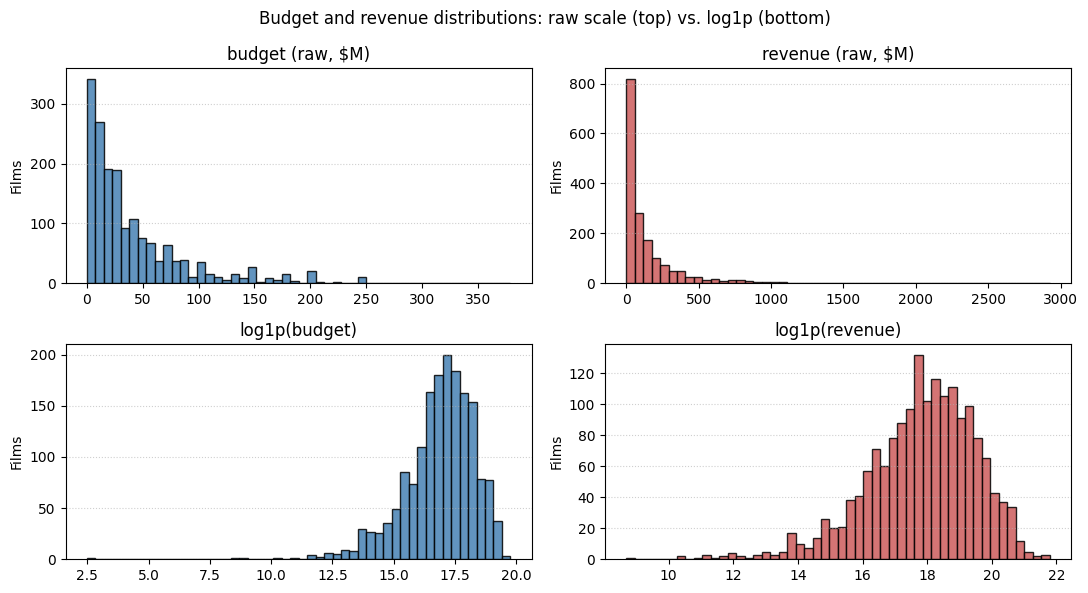

In [41]:
from src.data.build_corpus import compute_monetary_log

log_budget = compute_monetary_log(filtered["budget"], config.monetary_transform)
log_revenue = compute_monetary_log(filtered["revenue"], config.monetary_transform)

# Compare distributions before and after the transform.
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for col, raw, log_v, color, ax_top, ax_bot in (
    ("budget", filtered["budget"], log_budget, "steelblue", axes[0, 0], axes[1, 0]),
    ("revenue", filtered["revenue"], log_revenue, "indianred", axes[0, 1], axes[1, 1]),
):
    ax_top.hist(raw / 1e6, bins=50, color=color, edgecolor="black", alpha=0.85)
    ax_top.set(title=f"{col} (raw, $M)", ylabel="Films")
    ax_top.grid(axis="y", linestyle=":", alpha=0.6)

    ax_bot.hist(log_v, bins=50, color=color, edgecolor="black", alpha=0.85)
    ax_bot.set(title=f"log1p({col})", ylabel="Films")
    ax_bot.grid(axis="y", linestyle=":", alpha=0.6)
fig.suptitle("Budget and revenue distributions: raw scale (top) vs. log1p (bottom)")
fig.tight_layout()
plt.show()

The transformed distributions are approximately Gaussian
with the upper tail compressed, satisfying the standard
distributional assumptions of most regression models.

### 6.3 Genre-bucketed columns

**Justification.** Phase 1 EDA documented a long-tailed
genre distribution: Drama, Comedy, Thriller, and Action each
contain hundreds of films, while genres such as
Documentary, TV Movie, Foreign, and Western contain fewer
than thirty films each. Per-genre cross-validation slices in
Phase 4 require sufficiently populated cells to produce
stable per-stratum estimates; cells with fewer than
approximately thirty observations yield estimates with
unacceptably wide confidence intervals.

**Strategy.** Genres with population below the threshold
`genre_min_count` (default thirty) are collapsed into a
single `Other` category. The threshold is exposed as a
configuration parameter to support sensitivity analysis
across alternative values.

**Three columns saved.** Most films are tagged with multiple
genres, so the pipeline saves both the multi-label
`genres_bucketed` (a list of strings, with thin genres
replaced) and the single-label `primary_genre_bucketed`
(the first listed genre, similarly bucketed). The
un-bucketed `primary_genre` is retained for traceability.
Phase 4 selects the appropriate column per task: per-genre
stratified cross-validation uses `primary_genre_bucketed`,
while feature engineering that requires multi-label
information uses `genres_bucketed`.

In [42]:
from src.data.build_corpus import compute_primary_genre, bucket_genres

primary_genre = filtered["genres_parsed"].map(compute_primary_genre)
genres_bucketed, primary_bucketed, kept_genres = bucket_genres(
    filtered.assign(primary_genre=primary_genre),
    config.genre_min_count,
)
print(f"Genres retained (population ≥ {config.genre_min_count}):")
print(sorted(kept_genres))

pre = primary_genre.value_counts()
post = primary_bucketed.value_counts()
print(f"\nUnique primary_genre before bucketing: {pre.size}")
print(f"Unique primary_genre after bucketing:  {post.size}")
print(f"Films collapsed into 'Other': "
      f"{post.get('Other', 0):,} of {len(filtered):,}")

Genres retained (population ≥ 30):
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']

Unique primary_genre before bucketing: 17
Unique primary_genre after bucketing:  17
Films collapsed into 'Other': 8 of 1,713


Aggregating all derived-column computations into the canonical pipeline call:

In [43]:
from src.data.build_corpus import add_derived_columns

derived = add_derived_columns(filtered, config)
print(f"Corpus with derived columns: {len(derived):,} rows × "
      f"{len(derived.columns)} columns")
print(f"\nDerived columns added:")
new_cols = [c for c in derived.columns if c not in filtered.columns]
for c in new_cols:
    print(f"  {c}")

2026-05-03 00:52:15 | INFO    | src.data.build_corpus | Derived columns added. Kept genres (≥30 films): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']
Corpus with derived columns: 1,713 rows × 33 columns

Derived columns added:
  effective_rating
  log_budget
  log_revenue
  primary_genre
  genres_bucketed
  primary_genre_bucketed


---

## 7. Parse screenplay XML into structured form

**Justification.** Phase 1 verified the structure of the
MovieSum screenplay XML format but did not extract the
per-scene structure. Phase 2 implements a deterministic
parser that converts each `script` string into a
`ParsedScreenplay` dataclass containing an ordered list of
`Scene` objects. Each `Scene` contains its stage direction,
scene description, and ordered `(character, dialogue_text)`
pairs.

**Per-film outputs.** The parser produces:

* The full per-scene structure, serialized to
  `data/processed/screenplays_parsed.pkl` as `dict[imdb_id,
  ParsedScreenplay]`.
* Aggregate structural metrics, denormalized onto the master
  DataFrame: `n_scenes`, `n_unique_characters`,
  `n_dialogue_lines`, total character counts for dialogue,
  stage direction, and scene description, and two
  dialogue-to-action ratios.

**Edge-case handling.** Malformed XML is captured into a
degenerate `ParsedScreenplay` with empty scenes and the
parse error recorded in the object's `parse_warnings` field;
no exception is raised. The `<parenthetical>` element used
in screenplay convention for in-line stage cues
(for example, `(softly)` or `(beat)`) is recognized as a
continuation marker, so dialogue following a parenthetical
without an intervening `<character>` element is correctly
attributed to the preceding speaker.

**Two ratios.** The pipeline saves two related ratios to
accommodate both interpretations of "action" in a screenplay:

* `dialogue_to_action_ratio = total_dialogue_chars /
  (total_dialogue_chars + total_stage_direction_chars)`,
  where `stage_direction` corresponds to scene sluglines
  (for example, `INT. KITCHEN — DAY`).
* `dialogue_to_total_text_ratio = total_dialogue_chars /
  (total_dialogue_chars + total_action_chars)`, where
  `total_action_chars = total_stage_direction_chars +
  total_scene_description_chars`. This formulation includes
  the action paragraphs (scene descriptions) in the
  denominator and is more informative as a measure of
  dialogue density.

Both forms are saved; downstream phases select the form
appropriate to the feature being engineered.

### 7.1 Parse a single screenplay to illustrate the structure

In [ ]:
from src.data.parse_screenplay import parse_screenplay

sample = derived.iloc[0]
parsed_one = parse_screenplay(sample["script"], sample["imdb_id"])

print(f"Parsed: {sample['movie_name']}")
print(f"  imdb_id:                       {parsed_one.imdb_id}")
print(f"  n_scenes:                      {parsed_one.n_scenes}")
print(f"  n_unique_characters:           {parsed_one.n_unique_characters}")
print(f"  n_dialogue_lines:              {parsed_one.n_dialogue_lines}")
print(f"  total_dialogue_chars:          {parsed_one.total_dialogue_chars:,}")
print(f"  total_action_chars:            {parsed_one.total_action_chars:,}")
print(f"  dialogue_to_action_ratio:      {parsed_one.dialogue_to_action_ratio:.3f}")
print(f"  dialogue_to_total_text_ratio:  {parsed_one.dialogue_to_total_text_ratio:.3f}")
print(f"  parse_warnings:                {len(parsed_one.parse_warnings)}")

Parsed: 8MM_1999
  imdb_id:                       tt0134273
  n_scenes:                      282
  n_unique_characters:           31
  n_dialogue_lines:              871
  total_dialogue_chars:          55,728
  total_action_chars:            117,101
  dialogue_to_action_ratio:      0.846
  dialogue_to_total_text_ratio:  0.322
  parse_warnings:                0


Inspecting the first scene of the parsed screenplay:

In [45]:
first_scene = parsed_one.scenes[0]
print(f"Scene {first_scene.scene_number}:")
print(f"  stage_direction:   {first_scene.stage_direction[:100]!r}")
print(f"  scene_description: {first_scene.scene_description[:120]!r}")
print(f"  n dialogue_units:  {len(first_scene.dialogue_units)}")
if first_scene.dialogue_units:
    for char, line in first_scene.dialogue_units[:3]:
        print(f"    {char}: {line[:80]!r}")

Scene 1:
  stage_direction:   'INT.  MIAMI AIRPORT, TERMINAL -- DAY'
  scene_description: 'Amongst the weary tourist families and solitary businessmen sits TOM WELLES , middle - aged , hair neat , suit crisp and'
  n dialogue_units:  0


### 7.2 Parse the full corpus

In [46]:
from src.data.build_corpus import parse_all_screenplays

parsed_all = parse_all_screenplays(derived)
print(f"Parsed {len(parsed_all):,} screenplays")

warn_counts = pd.Series([
    len(p.parse_warnings) for p in parsed_all.values()
])
print(f"\nDistribution of parse warnings per film:")
print(f"  median: {int(warn_counts.median())}, "
      f"mean: {warn_counts.mean():.2f}, max: {int(warn_counts.max())}")
print(f"  films with at least one warning: {(warn_counts > 0).sum():,}")

2026-05-03 00:52:22 | INFO    | src.data.build_corpus | Parsed 1,713 screenplays (680 with warnings, 2,949 warnings total)
Parsed 1,713 screenplays

Distribution of parse warnings per film:
  median: 0, mean: 1.72, max: 114
  films with at least one warning: 680


The median parse-warning count per film is zero. Among films
with non-zero warnings, the warnings correspond to minor
structural irregularities in the source XML (for example,
a `<character>` element without a following `<dialogue>`)
rather than parse failures. No XML parse errors occurred in
the corpus.

### 7.3 Denormalize structural metrics onto the master DataFrame

In [47]:
from src.data.build_corpus import attach_screenplay_metrics

with_metrics = attach_screenplay_metrics(derived, parsed_all)
print(f"Final shape: {with_metrics.shape}")
print(f"\nStructural metric columns added:")
new_metric_cols = [c for c in with_metrics.columns if c not in derived.columns]
for c in new_metric_cols:
    print(f"  {c}")

Final shape: (1713, 43)

Structural metric columns added:
  n_scenes
  n_unique_characters
  n_dialogue_lines
  total_dialogue_chars
  total_stage_direction_chars
  total_scene_description_chars
  total_action_chars
  dialogue_to_action_ratio
  dialogue_to_total_text_ratio
  parse_warning_count


---

## 8. Persist the processed artifacts

Two artifacts are written to `data/processed/`.

**`films_joined.parquet`.** One row per film with all source
and derived columns. Apache Parquet is selected as the
storage format for three reasons: it preserves dtypes
(including list-valued columns such as `genres_parsed` and
`genres_bucketed`), it is substantially more compact than
CSV (in this corpus, 409 KB versus an estimated 3-5 MB CSV
equivalent), and it loads faster as a binary columnar
format. The `script` and `summary` text columns are excluded
from the Parquet to avoid duplication: the screenplay text
is preserved in the structured pickle artifact described
below.

**`screenplays_parsed.pkl`.** A pickle of `dict[imdb_id,
ParsedScreenplay]`. Pickle is used rather than Parquet
because the artifact contains nested Python dataclass
objects (`ParsedScreenplay` instances containing tuples of
`Scene` instances containing tuples of dialogue pairs).
Parquet's nested type support is awkward for arbitrary
dataclasses, while pickle handles them natively. The pickle
format is appropriate here because the artifact is
consumed exclusively by downstream Python code in this
project.

In [48]:
from src.data.build_corpus import save_artifacts

parquet_path, pkl_path = save_artifacts(
    with_metrics, parsed_all, config.out_dir,
)
print(f"Saved: {parquet_path.name}  ({parquet_path.stat().st_size / 1024:.0f} KB)")
print(f"Saved: {pkl_path.name}  ({pkl_path.stat().st_size / 1024 / 1024:.0f} MB)")

2026-05-03 00:52:22 | INFO    | src.data.build_corpus | Saved master parquet: 1,713 rows
2026-05-03 00:52:23 | INFO    | src.data.build_corpus | Saved parsed-screenplays pickle: 1,713 entries
Saved: films_joined.parquet  (409 KB)
Saved: screenplays_parsed.pkl  (228 MB)


---

## 9. Validate the processed corpus

**Justification.** Validation guards downstream code against
silently propagating data-quality regressions. The validator
encodes every invariant the master Parquet must satisfy as
a hard assertion; any violation halts execution
immediately. The validator is also runnable as a standalone
smoke test, supporting use as a continuous-integration
check.

**Invariants enforced:**

* `imdb_id` is unique and non-null.
* `effective_rating` is non-null and in [0, 10].
* `budget` and `revenue` are strictly positive.
* `release_year_parsed` is non-null and in [1900, 2025].
* `log_budget` and `log_revenue` are non-null, finite, and
  positive.
* `primary_genre` and `primary_genre_bucketed` are non-null.
* `n_scenes` is strictly positive.
* Both dialogue-to-action ratios are in [0, 1].

In [49]:
from src.data.validate_processed_corpus import (
    load_processed_corpus, hard_asserts, summary_metrics_table,
)

# Load from disk to verify the round-trip preserves all invariants.
df = load_processed_corpus()
hard_asserts(df)
print(f"All invariants satisfied ({len(df):,} films, "
      f"{len(df.columns)} columns)")

summary_metrics_table(df)

2026-05-03 00:52:23 | INFO    | src.data.validate_processed_corpus | Loaded processed corpus: 1,713 films × 41 columns
2026-05-03 00:52:23 | INFO    | src.data.validate_processed_corpus | All hard assertions passed (1713 films, 41 columns)
All invariants satisfied (1,713 films, 41 columns)


,metric,value
0,films_total,1.713000e+03
1,year_min,1.932000e+03
2,year_max,2.023000e+03
3,year_median,2.005000e+03
4,budget_median_usd,2.500000e+07
5,budget_mean_usd,4.217357e+07
6,revenue_median_usd,6.441476e+07
7,revenue_mean_usd,1.544162e+08
8,rating_mean,6.943000e+00
9,rating_median,7.000000e+00


---

## 10. Profile the processed corpus

Diagnostic plots characterizing the final 1,713-film
corpus. Each figure is also saved to `reports/figures/` for
inclusion in the project's final report.

### 10.1 Year distribution

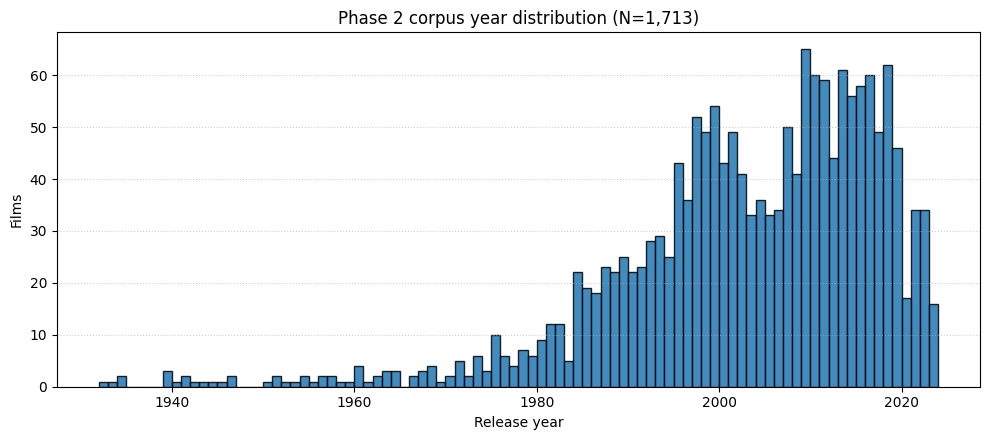

In [50]:
from src.data.validate_processed_corpus import plot_year_distribution

plot_year_distribution(
    df, paths.REPORTS_FIGURES_DIR / "phase2_year_distribution.png"
)
plt.show()

The corpus exhibits a dense main body covering 1995 to 2022
and a thinner historical tail extending to 1932.
Era-stratified cross-validation in Phase 4 will group
pre-1980s decades (each containing fewer than thirty films)
into a single stratum to ensure stable per-decade estimates.

### 10.2 Genre distribution

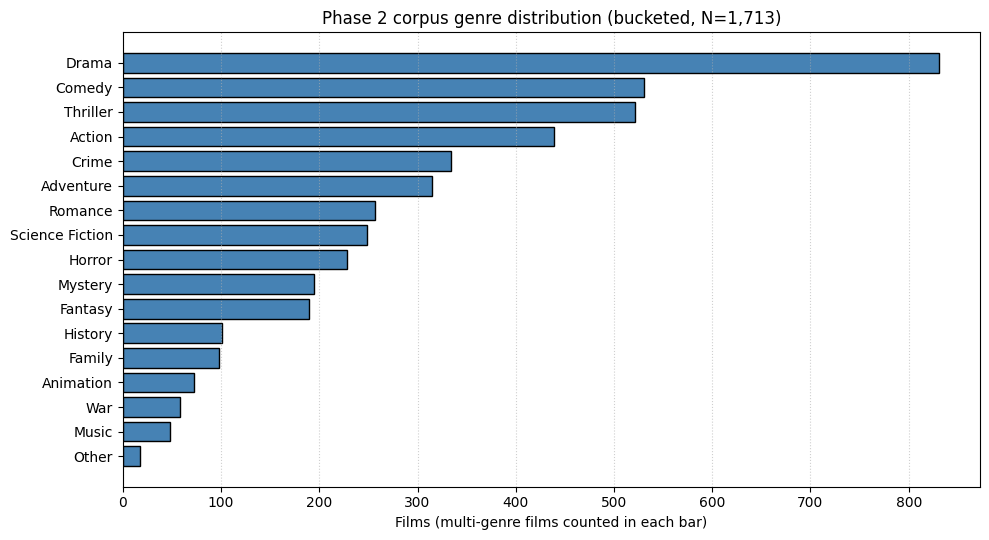

In [51]:
from src.data.validate_processed_corpus import plot_genre_distribution

plot_genre_distribution(
    df, paths.REPORTS_FIGURES_DIR / "phase2_genre_distribution.png"
)
plt.show()

Drama, Comedy, Thriller, and Action lead the distribution,
as is typical of Hollywood output in this era. Genres with
population below thirty films have been collapsed into the
`Other` category, ensuring that per-genre stratified
analyses in Phase 4 operate on well-conditioned cells.

### 10.3 Budget and revenue distributions (raw and log scales)

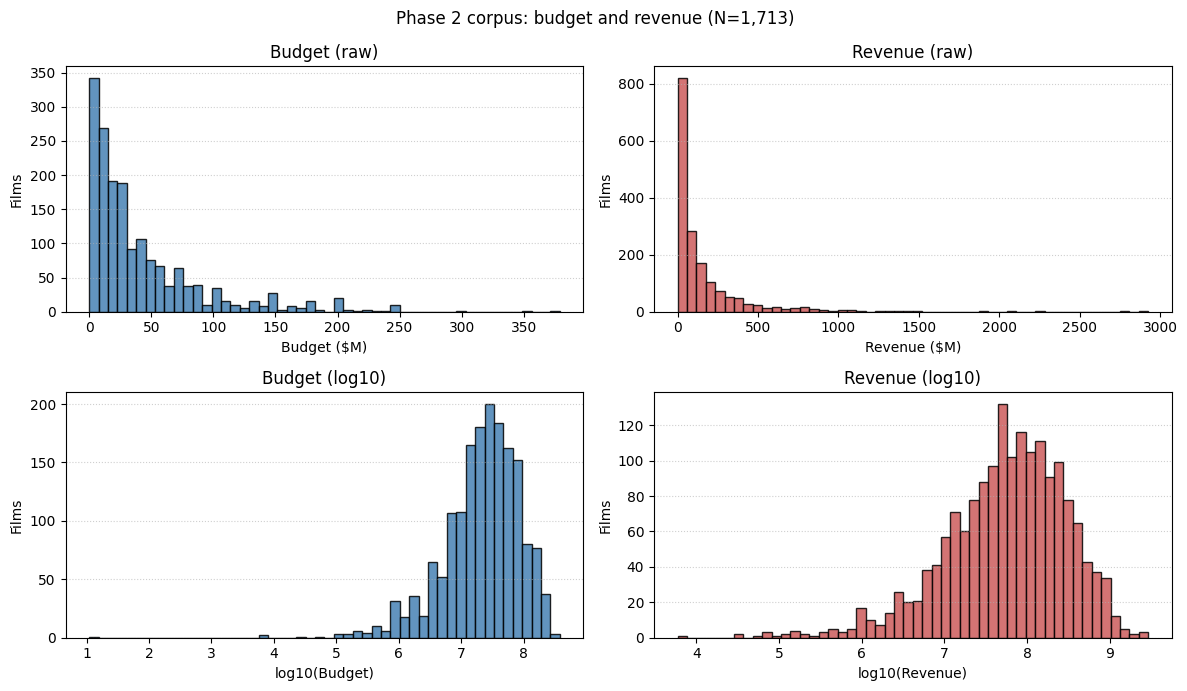

In [52]:
from src.data.validate_processed_corpus import plot_budget_revenue

plot_budget_revenue(
    df, paths.REPORTS_FIGURES_DIR / "phase2_budget_revenue_distribution.png"
)
plt.show()

The raw-scale histograms exhibit pronounced right-skew that
motivates the logarithmic transform discussed in Section 6.2.
The log10-transformed panels approximate Gaussian shape and
are the appropriate inputs for downstream regression
modelling.

### 10.4 Rating, ROI, and screenplay length

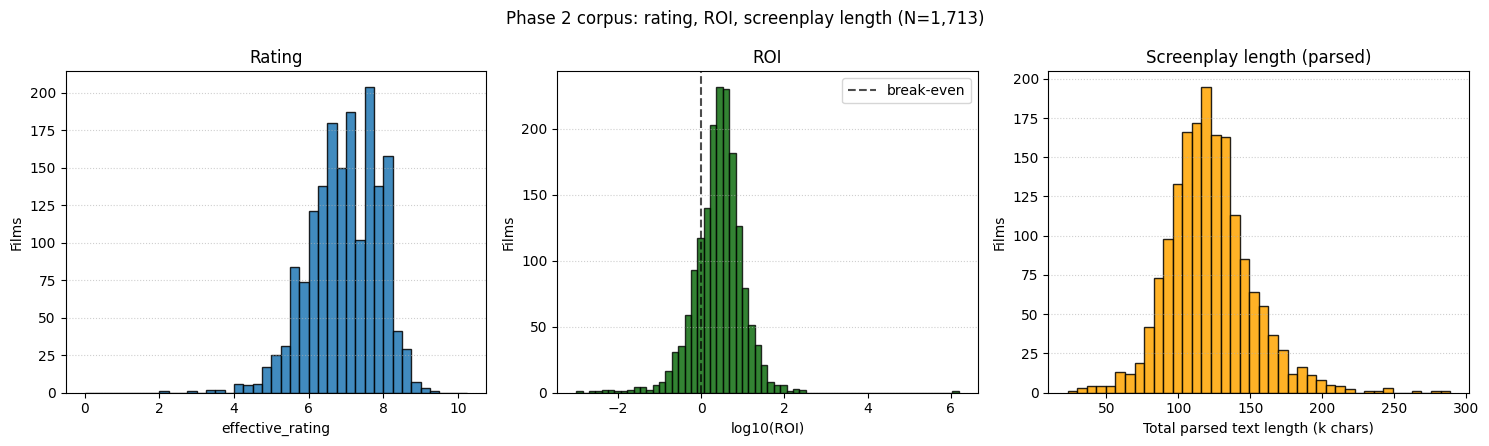

In [53]:
from src.data.validate_processed_corpus import plot_rating_roi_length

plot_rating_roi_length(
    df, paths.REPORTS_FIGURES_DIR / "phase2_rating_roi_length.png"
)
plt.show()

The rating distribution is approximately Gaussian with mean
near 7.0 and a narrow standard deviation. This limited
dynamic range constrains the achievable predictive
coefficient of determination in Phase 4; the project's
novelty contribution is therefore concentrated in the
downstream layers (calibrated uncertainty in Phase 5,
asymmetric-cost decision-making in Phase 6) rather than in
headline regression accuracy.

The return-on-investment distribution is heavily
right-tailed, with the break-even line (log10 ROI = 0)
positioned to the left of the bulk of the distribution.
Approximately 80 percent of films in the corpus are
gross-profitable; this rate substantially exceeds
the industry's net-profitability rate of approximately 50
percent, reflecting survivorship bias in the corpus
(films that were both produced and recognized enough to
appear in a major metadata aggregator). Phase 6's cost
matrix is therefore calibrated against external industry
base rates rather than corpus rates, with sensitivity
analysis across alternative cost matrices in Phase 8.

The screenplay-length distribution is approximately
bell-shaped centered near 200,000 characters of parsed
text, consistent with feature-length screenplay
conventions.

### 10.5 Screenplay-structural features

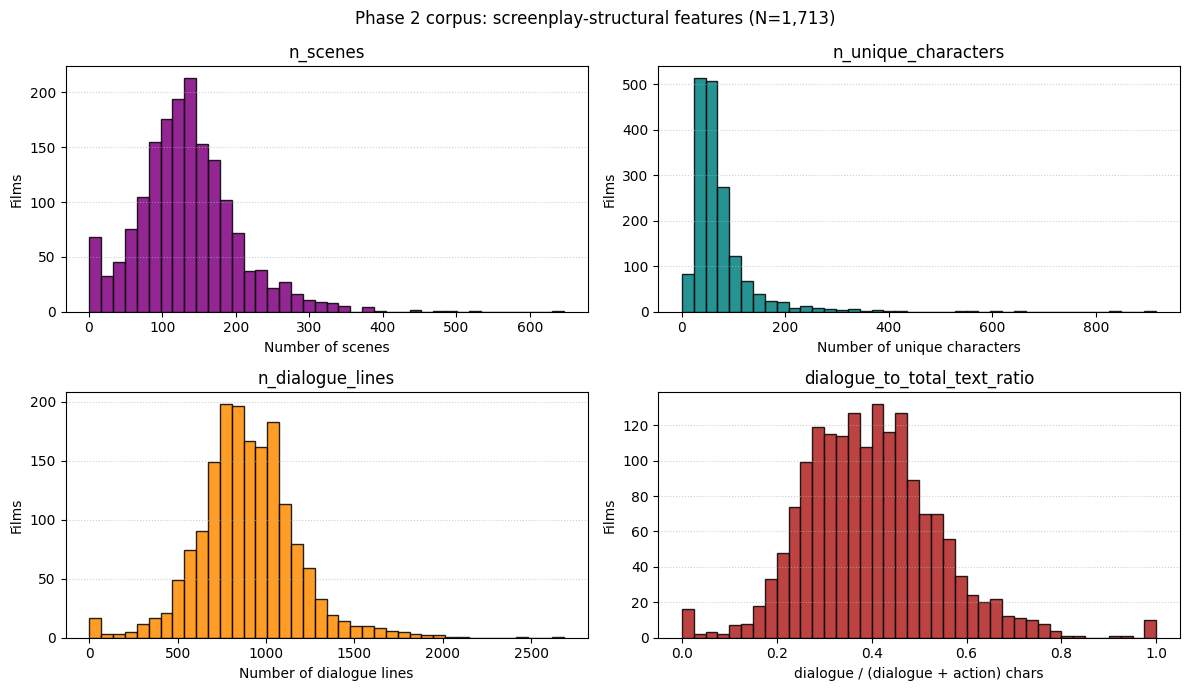

In [54]:
from src.data.validate_processed_corpus import plot_screenplay_structure

plot_screenplay_structure(
    df, paths.REPORTS_FIGURES_DIR / "phase2_screenplay_structure.png"
)
plt.show()

Four structural distributions:

* `n_scenes`: right-skewed, median 130. A small subset of
  long-form scripts contain over 400 scenes.
* `n_unique_characters`: right-skewed, median 56. Most
  screenplays employ a tractable principal cast; a small
  number of ensemble works exceed 200 distinct characters.
* `n_dialogue_lines`: right-skewed, median 880. The
  distribution mirrors total script length.
* `dialogue_to_total_text_ratio`: approximately bell-shaped
  centered near 0.4, with substantial dispersion. The
  spread (some screenplays exceed 0.6, others fall below
  0.25) reflects genuine stylistic variation between
  dialogue-heavy and action-heavy screenplays. This feature
  is expected to carry meaningful predictive signal in
  Phase 3.

---

## 11. Per-decade and per-genre summary tables

The two tables below inform Phase 4's stratification design
and are saved as CSV files under `reports/tables/`.

### 11.1 Per-decade summary

In [55]:
from src.data.validate_processed_corpus import per_decade_table
per_decade_table(df)

,decade,n_films,budget_median_M,revenue_median_M,rating_mean,scenes_median,dialogue_lines_median
0,1930,7,0.70,4.50,7.63,2.0,1363.0
1,1940,9,0.88,4.90,8.00,76.0,1061.0
2,1950,14,1.24,9.00,7.91,92.5,1004.5
3,1960,23,2.50,25.00,7.81,98.0,870.0
4,1970,51,3.50,46.67,7.40,90.0,869.0
5,1980,167,15.00,44.80,6.86,128.0,810.0
6,1990,361,30.00,59.49,6.86,127.0,883.0
7,2000,425,40.00,83.28,6.88,141.0,896.0
8,2010,555,25.00,77.07,6.96,130.0,883.0
9,2020,101,35.00,46.33,6.84,117.0,914.0


Decadal cell counts confirm that the 1930s through 1970s
each contain fewer than thirty films, motivating their
consolidation into a single "older films" stratum for
Phase 4 cross-validation. Decades from the 1980s onward have
well-conditioned cell sizes and can be treated as
independent strata.

### 11.2 Per-genre summary

In [56]:
from src.data.validate_processed_corpus import per_genre_table
per_genre_table(df)

,primary_genre_bucketed,n_films,budget_median_M,revenue_median_M,rating_mean,roi_median
5,Drama,431,18.00,40.26,7.09,2.55
3,Comedy,312,18.00,52.50,6.72,3.01
0,Action,239,55.00,139.20,6.92,2.52
9,Horror,147,11.00,47.97,6.63,4.03
1,Adventure,121,65.00,263.92,7.17,3.23
4,Crime,101,18.00,45.28,7.15,2.57
15,Thriller,83,32.00,78.87,6.88,2.48
14,Science Fiction,66,40.00,92.69,6.94,2.46
7,Fantasy,47,54.00,151.93,7.00,3.15
2,Animation,45,80.00,348.84,7.21,3.84


Drama is the largest genre, followed by Comedy and Action.
Per-genre median budget, revenue, and rating values reveal
systematic differences between genres: action films have
the highest median budgets and revenues, drama films the
highest median rating, and horror exhibits low median
budgets paired with high median return-on-investment.
These differences support the case for genre as an
important feature group in Phase 3.

---

## 12. Phase 2 Conclusion

### Outputs

* `data/processed/films_joined.parquet`: 1,713 films across
  41 columns, comprising source metadata, derived columns,
  and screenplay-structural metrics.
* `data/processed/screenplays_parsed.pkl`: 1,713
  `ParsedScreenplay` objects with full per-scene structure.
* Five diagnostic figures and three summary tables under
  `reports/figures/` and `reports/tables/`, named with the
  `phase2_` prefix.
* `docs/DATA_NOTES.md`: a standing reference document
  comprising the column glossary, known biases, and
  edge-case documentation.

### Key methodological notes for downstream phases

* **Sentinel encoding for monetary fields.** The values
  `budget = 0` and `revenue = 0` are missing-data sentinels
  inherited from the ratings source. The processed corpus
  excludes such rows; any future analysis that re-loads the
  raw data must re-apply this convention.
* **Survivorship bias.** The corpus is biased toward films
  that were both produced and well-recognized, with a gross
  profitability rate substantially above the industry net
  rate. The Phase 6 cost matrix uses external industry
  rates, and Phase 8 conducts sensitivity analysis across
  alternative cost configurations.
* **`<parenthetical>` elements.** Recognized as continuation
  markers but not stored separately; the
  `dialogue_units` schema specifies two-tuples of
  `(character, dialogue_text)`.
* **Two dialogue-to-action ratios available.** Phase 3
  selects the form appropriate to each engineered feature.
* **Configuration knobs.** All preprocessing decisions
  discussed above are exposed as parameters in
  `CorpusBuildConfig`. Alternative configurations
  (different year cutoffs, alternative monetary transforms,
  alternative bucketing thresholds) can be evaluated by
  overriding the relevant fields and rebuilding.

### Inputs to Phase 3

Phase 3 reads `films_joined.parquet` for film-level
metadata and outcomes, and `screenplays_parsed.pkl` for
per-scene structure. Phase 3 will:

1. Construct a train / calibration / test partition of the
   corpus.
2. Define and apply post-split imputation strategies.
3. Extract dialogue features (lexical, sentiment, topic,
   embedding, structural).
4. Save the resulting feature matrix to
   `data/processed/features.parquet`.

Detailed column documentation is available in
`docs/DATA_NOTES.md`. Methodological rationale and audit
trail are documented in `docs/summaries/phase_2_summary.md`.